In [28]:
# Environment setup: imports and default winding (with explicit reloads)
import os, sys, importlib
import numpy as np
import matplotlib.pyplot as plt

# Ensure src/ is on Python path
src_path = os.path.join(os.getcwd(), 'src')
if src_path not in sys.path:
    sys.path.append(src_path)

# Import and reload open circuit field module for iterative development
import open_circuit_field as _ocf_mod
importlib.reload(_ocf_mod)
from open_circuit_field import OpenCircuitField, MotorGeometry, MagnetProperties, WindingConfiguration


In [29]:
# Thickness-based geometry definition (replaces direct radii entry)
# All dimensions in meters
stator_outer_diameter = 0.082   
stator_thickness = 0.008        
airgap = 0.001          
magnet_thickness = 0.004       
rotor_thickness = 0.01        

winding = WindingConfiguration(
    phases=3,
    turns_per_coil=13,
    parallel_branches=2,          # 2 coils in parallel per phase
    current_density=28,           
    wire_width=1e-3,               # in mm
    wire_height=2.5e-3             # in mm
)

geometry = MotorGeometry.from_thicknesses(
    stator_outer_diameter=stator_outer_diameter,
    stator_thickness=stator_thickness,
    airgap_length=airgap + winding.wire_height,
    magnet_thickness=magnet_thickness,
    rotor_thickness=rotor_thickness,
    axial_length=0.150,
    pole_pairs=2,
    min_shaft_radius=0.0,
)

magnet = MagnetProperties(
    residual_flux_density=1.2,
    relative_permeability=1.05,
    coercivity=900000,
    magnet_thickness=magnet_thickness,
    magnet_arc_ratio=0.96,
)


## Initialize Open Circuit Field Calculator

Create the OpenCircuitField object and display the derived parameters.

In [30]:
# Create open circuit field calculator
field_calc = OpenCircuitField(geometry, magnet)

print("Derived Parameters (clarified magnet radii):")
print(f"- Rs (stator inner / airgap outer): {field_calc.Rs*1000:.2f} mm")
print(f"- g  (airgap length): {field_calc.g*1000:.2f} mm")
print(f"- Magnet outer radius (Rm_out): {field_calc.Rm_out*1000:.2f} mm")
print(f"- Magnet inner radius (Rm_in): {field_calc.Rm_in*1000:.2f} mm")
print(f"- Rotor back-iron outer (Rr): {field_calc.Rr*1000:.2f} mm")
print(f"- Pole pitch: {field_calc.pole_pitch*180/np.pi:.2f} degrees")
print(f"- Magnet arc: {field_calc.magnet_arc*180/np.pi:.2f} degrees")

Derived Parameters (clarified magnet radii):
- Rs (stator inner / airgap outer): 33.00 mm
- g  (airgap length): 3.50 mm
- Magnet outer radius (Rm_out): 29.50 mm
- Magnet inner radius (Rm_in): 25.50 mm
- Rotor back-iron outer (Rr): 25.50 mm
- Pole pitch: 90.00 degrees
- Magnet arc: 86.40 degrees


## Fourier Coefficients Analysis

Calculate and display the Fourier coefficients for the magnetization distribution.

In [31]:
# Calculate Fourier coefficients
n_harmonics = 10
harmonic_orders, magnetization_coeffs = field_calc.fourier_coefficients(n_harmonics)

print(f"Magnetization Fourier Coefficients:")
print(f"{'Harmonic':<10} {'Order (np)':<12} {'Mn (A/m)':<15}")
print("-" * 40)
for i, (np_val, Mn) in enumerate(zip(harmonic_orders, magnetization_coeffs)):
    print(f"{i+1:<10} {np_val:<12} {Mn:.2e}")

Magnetization Fourier Coefficients:
Harmonic   Order (np)   Mn (A/m)       
----------------------------------------
1          2            1.21e+06
2          6            -3.98e+05
3          10           2.31e+05
4          14           -1.57e+05
5          18           1.14e+05
6          22           -8.52e+04
7          26           6.40e+04
8          30           -4.76e+04
9          34           3.45e+04
10         38           -2.36e+04


Equation Results at radius 0.03175 m:
- Maximum BH: 0.5738 T
- Minimum BH: -0.5738 T
- Peak-to-peak: 1.1476 T
- RMS value: 0.5274 T


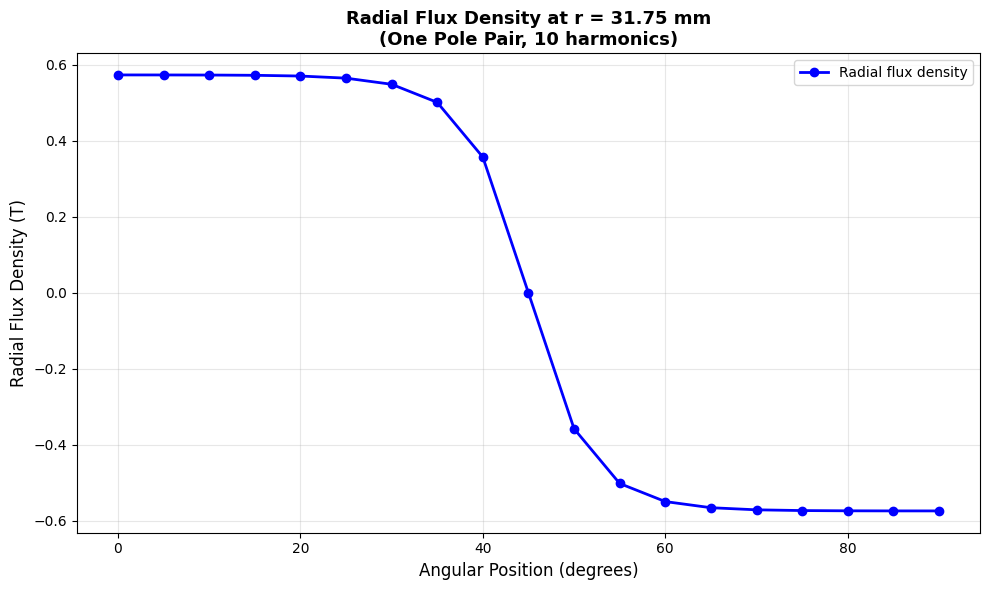

In [32]:
# Define angular positions for one pole pair
theta = np.linspace(0, np.pi/geometry.pole_pairs, 19)
theta_degrees = theta * 180 / np.pi
radius_in_gap = geometry.stator_inner_radius - winding.wire_height/2
# Calculate radial flux density at radius in air gap

field_distribution = field_calc.radial_flux_density_in_gap_at_radius(radius_in_gap, theta, n_harmonics=20)

print(f"Equation Results at radius {radius_in_gap:.5f} m:")
print(f"- Maximum BH: {np.max(field_distribution):.4f} T")
print(f"- Minimum BH: {np.min(field_distribution):.4f} T")
print(f"- Peak-to-peak: {np.max(field_distribution) - np.min(field_distribution):.4f} T")
print(f"- RMS value: {np.sqrt(np.mean(field_distribution**2)):.4f} T")

# Plot field distribution
plt.figure(figsize=(10, 6))
plt.plot(theta_degrees, field_distribution, 'b-o', linewidth=2, markersize=6, label='Radial flux density')
plt.xlabel('Angular Position (degrees)', fontsize=12)
plt.ylabel('Radial Flux Density (T)', fontsize=12)
plt.title(f'Radial Flux Density at r = {radius_in_gap*1000:.2f} mm\n(One Pole Pair, {n_harmonics} harmonics)', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

## Simplified Average Torque Calculation

Direct calculation of average electromagnetic torque without Park transform or angle sweep.
Uses the torque constant approach: T = Kt × I, where Kt = 1.5 × p × ψ_pm

In [33]:
# Simplified average torque calculation (no Park transform needed)
import numpy as np

# Operating parameters
J_fixed = 26.0  # A/mm² current density
p = geometry.pole_pairs

# Calculate flux linkage per coil
radius_calc = geometry.stator_inner_radius - winding.wire_height/2
psi_per_turn = field_calc.flux_linkage_per_turn(radius_calc, n_harmonics=20)
phase_psi = psi_per_turn * winding.turns_per_coil

# Calculate phase current (accounting for parallel branches)
I_per_branch = winding.current_per_branch(J_fixed)
I_phase_peak = winding.phase_current(J_fixed)

# Direct average torque calculation
# T_avg = 1.5 × p × ψ_pm × I_q
# For optimal sinusoidal excitation, I_q = I_phase
T_avg = 1.5 * p * phase_psi * I_phase_peak

# Torque constant
K_t = 1.5 * p * phase_psi

print("=" * 80)
print("SIMPLIFIED AVERAGE TORQUE CALCULATION")
print("=" * 80)
print(f"\nGeometry & Winding:")
print(f"  Pole pairs: {p}")
print(f"  Turns per coil: {winding.turns_per_coil}")
print(f"  Parallel branches: {winding.parallel_branches}")
print(f"  Calculation radius: {radius_calc*1000:.2f} mm")

print(f"\nFlux Linkage:")
print(f"  Per turn: {psi_per_turn:.5e} Wb")
print(f"  Per coil: {phase_psi:.5e} Wb")

print(f"\nCurrent:")
print(f"  Current density: {J_fixed:.1f} A/mm²")
print(f"  Current per branch: {I_per_branch:.3f} A")
print(f"  Total phase current: {I_phase_peak:.3f} A")
print(f"  RMS phase current: {I_phase_peak/np.sqrt(2):.3f} A")

print(f"\nTorque:")
print(f"  Torque constant Kt: {K_t:.5f} Nm/A")
print(f"  Average torque: {T_avg:.3f} Nm")

print("=" * 80)

SIMPLIFIED AVERAGE TORQUE CALCULATION

Geometry & Winding:
  Pole pairs: 2
  Turns per coil: 13
  Parallel branches: 2
  Calculation radius: 31.75 mm

Flux Linkage:
  Per turn: 3.81355e-03 Wb
  Per coil: 4.95762e-02 Wb

Current:
  Current density: 26.0 A/mm²
  Current per branch: 65.000 A
  Total phase current: 130.000 A
  RMS phase current: 91.924 A

Torque:
  Torque constant Kt: 0.14873 Nm/A
  Average torque: 19.335 Nm


## Back-EMF Calculation

Calculate the back-EMF induced in the windings based on Zhu's equation (35).
The EMF constant Ke relates back-EMF to speed, and equals the torque constant Kt in SI units.

In [34]:
# Back-EMF calculation at rated speed
import numpy as np

# Operating speed
rpm_rated = 3000  # rpm
omega_r = rpm_rated * 2 * np.pi / 60  # rad/s (mechanical)
freq_elec = p * rpm_rated / 60  # Hz (electrical frequency)

# Calculation radius (same as torque calculation)
radius_calc = geometry.stator_inner_radius - winding.wire_height/2

# Calculate back-EMF per turn
emf_per_turn_peak = field_calc.back_emf_per_turn(radius_calc, omega_r, n_harmonics=20)

# Calculate RMS back-EMF per phase
emf_rms_phase = field_calc.back_emf_rms_per_phase(radius_calc, omega_r, winding, n_harmonics=20)

# Calculate EMF constant
Ke = field_calc.emf_constant(radius_calc, winding, n_harmonics=20)

# Line-to-line voltage (for wye connection)
emf_rms_line = emf_rms_phase * np.sqrt(3)

print("=" * 80)
print("BACK-EMF CALCULATION (Zhu Equation 35)")
print("=" * 80)

print(f"\nOperating Conditions:")
print(f"  Speed: {rpm_rated} rpm ({omega_r:.2f} rad/s)")
print(f"  Electrical frequency: {freq_elec:.2f} Hz")
print(f"  Pole pairs: {p}")
print(f"  Calculation radius: {radius_calc*1000:.2f} mm")

print(f"\nBack-EMF:")
print(f"  Peak EMF per turn: {emf_per_turn_peak:.4f} V")
print(f"  RMS phase voltage: {emf_rms_phase:.2f} V")
print(f"  RMS line-to-line voltage: {emf_rms_line:.2f} V")

print(f"\nMotor Constants:")
print(f"  EMF constant Ke: {Ke:.5f} V·s/rad ({Ke*60/(2*np.pi):.4f} V/krpm)")
print(f"  Torque constant Kt: {K_t:.5f} Nm/A")
print(f"  Ke vs Kt ratio: {Ke/K_t:.6f} (should ≈ 1.0 in SI units)")

print(f"\nValidation:")
print(f"  EMF at {rpm_rated} rpm: {emf_rms_phase:.2f} V")
print(f"  EMF = Ke × ω check: {Ke * omega_r:.2f} V")
print(f"  Torque at {I_phase_peak:.1f} A: {T_avg:.2f} Nm")
print(f"  Torque = Kt × I check: {K_t * I_phase_peak:.2f} Nm")

print("=" * 80)

BACK-EMF CALCULATION (Zhu Equation 35)

Operating Conditions:
  Speed: 3000 rpm (314.16 rad/s)
  Electrical frequency: 100.00 Hz
  Pole pairs: 2
  Calculation radius: 31.75 mm

Back-EMF:
  Peak EMF per turn: 3.1974 V
  RMS phase voltage: 29.39 V
  RMS line-to-line voltage: 50.91 V

Motor Constants:
  EMF constant Ke: 0.09356 V·s/rad (0.8934 V/krpm)
  Torque constant Kt: 0.14873 Nm/A
  Ke vs Kt ratio: 0.629051 (should ≈ 1.0 in SI units)

Validation:
  EMF at 3000 rpm: 29.39 V
  EMF = Ke × ω check: 29.39 V
  Torque at 130.0 A: 19.33 Nm
  Torque = Kt × I check: 19.33 Nm


0.15600000000000003
0.20096
Calculated flux linkage per turn at radius 0.03075 m: 3.69161e-01 Wb


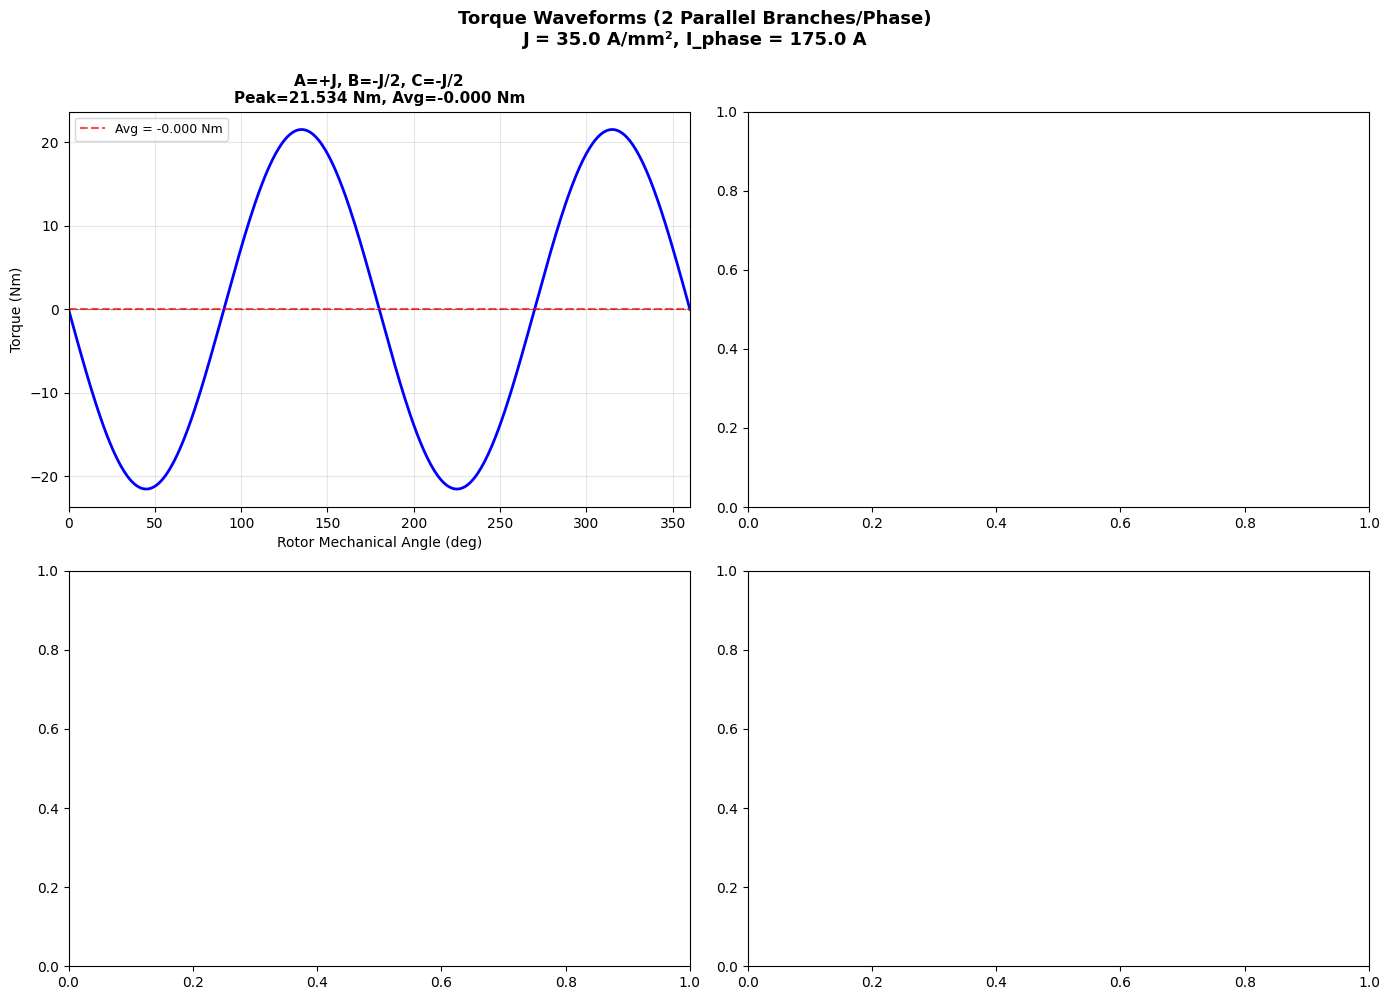


DETAILED WAVEFORM ANALYSIS AT J = 35.0 A/mm² (amplitude)
Configuration: 2 branches in parallel per phase
Phase current: I_peak = 175.000 A, I_rms = 123.744 A
Current per branch: 87.500 A
Flux linkage per coil: ψ = 4.10178e-02 Wb
Pole pairs: p = 2

A=+J, B=-J/2, C=-J/2          
  Phase currents (peak): ia= 175.00 A, ib= -87.50 A, ic= -87.50 A
  Torque stats: Min=-21.534 Nm, Max= 21.534 Nm
                Avg= -0.000 Nm, RMS= 15.206 Nm
  Torque ripple: 43.069 Nm (peak-to-peak)



In [13]:
# Compare torque waveforms for all static patterns at J = 28 A/mm²
import numpy as np
import matplotlib.pyplot as plt

# Fixed current density
J_fixed = 35.0  # A/mm²

# Use winding methods to calculate phase current (methods handle A/mm² directly)
I_per_branch = winding.current_per_branch(J_fixed)
I_phase_peak = winding.phase_current(J_fixed)

# Define patterns
patterns_waveform = {
    'A=+J, B=-J/2, C=-J/2': lambda I: (I, -0.5*I, -0.5*I),
}
print(winding.wire_width * winding.turns_per_coil * 3 * 4)
print(2*3.14*(stator_outer_diameter/2 - stator_thickness))
phase_psi = field_calc.flux_linkage_per_turn(radius_in_gap, n_harmonics=20) * winding.turns_per_coil

print(f"Calculated flux linkage per turn at radius {radius_in_gap:.5f} m: {phase_psi*9:.5e} Wb")

# Angle sweep
mech_deg = np.linspace(0.0, 360.0, 361)
mech_rad = np.deg2rad(mech_deg)
elec_rad = p * mech_rad

# Park transform
cos_th = np.cos(elec_rad)
sin_th = np.sin(elec_rad)
cos_th_m120 = np.cos(elec_rad - 2*np.pi/3)
sin_th_m120 = np.sin(elec_rad - 2*np.pi/3)
cos_th_p120 = np.cos(elec_rad + 2*np.pi/3)
sin_th_p120 = np.sin(elec_rad + 2*np.pi/3)
k = 2.0/3.0

# Compute torque waveforms
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (pattern_name, pattern_func) in enumerate(patterns_waveform.items()):
    # Static abc currents
    ia, ib, ic = pattern_func(I_phase_peak)
    
    # Broadcast if scalars
    if np.isscalar(ia):
        ia = np.full_like(mech_rad, ia)
        ib = np.full_like(mech_rad, ib)
        ic = np.full_like(mech_rad, ic)
    
    # Transform to dq
    i_d = k * (ia * cos_th + ib * cos_th_m120 + ic * cos_th_p120)
    i_q = -k * (ia * sin_th + ib * sin_th_m120 + ic * sin_th_p120)
    
    # Torque (using total phase current and single coil flux linkage)
    T_e = 1.5 * p * phase_psi * i_q
    
    # Plot
    ax = axes[idx]
    ax.plot(mech_deg, T_e, 'b-', linewidth=2)
    ax.axhline(0, color='k', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.axhline(np.mean(T_e), color='r', linewidth=1.5, linestyle='--', alpha=0.7, 
               label=f'Avg = {np.mean(T_e):.3f} Nm')
    ax.set_xlabel('Rotor Mechanical Angle (deg)', fontsize=10)
    ax.set_ylabel('Torque (Nm)', fontsize=10)
    ax.set_title(f'{pattern_name}\nPeak={np.max(np.abs(T_e)):.3f} Nm, Avg={np.mean(T_e):.3f} Nm', 
                 fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    ax.set_xlim([0, 360])

plt.suptitle(f'Torque Waveforms ({winding.parallel_branches} Parallel Branches/Phase)\nJ = {J_fixed:.1f} A/mm², I_phase = {I_phase_peak:.1f} A', 
             fontsize=13, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Print detailed analysis
print("\n" + "="*80)
print(f"DETAILED WAVEFORM ANALYSIS AT J = {J_fixed:.1f} A/mm² (amplitude)")
print("="*80)
print(f"Configuration: {winding.parallel_branches} branches in parallel per phase")
print(f"Phase current: I_peak = {I_phase_peak:.3f} A, I_rms = {I_phase_peak/np.sqrt(2):.3f} A")
print(f"Current per branch: {I_per_branch:.3f} A")
print(f"Flux linkage per coil: ψ = {phase_psi:.5e} Wb")
print(f"Pole pairs: p = {p}\n")

for pattern_name, pattern_func in patterns_waveform.items():
    ia, ib, ic = pattern_func(I_phase_peak)
    if np.isscalar(ia):
        ia = np.full_like(mech_rad, ia)
        ib = np.full_like(mech_rad, ib)
        ic = np.full_like(mech_rad, ic)
    
    i_d = k * (ia * cos_th + ib * cos_th_m120 + ic * cos_th_p120)
    i_q = -k * (ia * sin_th + ib * sin_th_m120 + ic * sin_th_p120)
    T_e = 1.5 * p * phase_psi * i_q
    
    print(f"{pattern_name:30s}")
    print(f"  Phase currents (peak): ia={ia[0]:7.2f} A, ib={ib[0]:7.2f} A, ic={ic[0]:7.2f} A")
    print(f"  Torque stats: Min={np.min(T_e):7.3f} Nm, Max={np.max(T_e):7.3f} Nm")
    print(f"                Avg={np.mean(T_e):7.3f} Nm, RMS={np.sqrt(np.mean(T_e**2)):7.3f} Nm")
    print(f"  Torque ripple: {(np.max(T_e) - np.min(T_e)):.3f} Nm (peak-to-peak)\n")

print("="*80)